In [24]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

A company is planing to launch a campaign for their new car brand, and would like to analyze which customer are most likely to purchase the car so that the ads can be
design to specificlly target that customer , in order to achive this, 
they consult a social network advertisement company that posses the data for another similer campaign. it is now desire to construct a model to achive the goal. use the 
logisctic regression to predict if a customer is going to buy a car or not.

In [25]:
purchaseData = pd.read_csv("Purchase_Logistics.csv")
X = purchaseData.iloc[:,[2,3]].values
y = purchaseData.iloc[:,4].values 

In [26]:
# print(X)
# print(y)

print(purchaseData.sample(5))

      User ID  Gender  Age  EstimatedSalary  Purchased
6    15598044  Female   27            84000          0
62   15595135  Female   23            66000          0
147  15749130  Female   41            30000          0
159  15598840  Female   32           135000          1
99   15756820  Female   28            37000          0


In [27]:
purchaseData.shape

(400, 5)

In [28]:
y.shape

(400,)

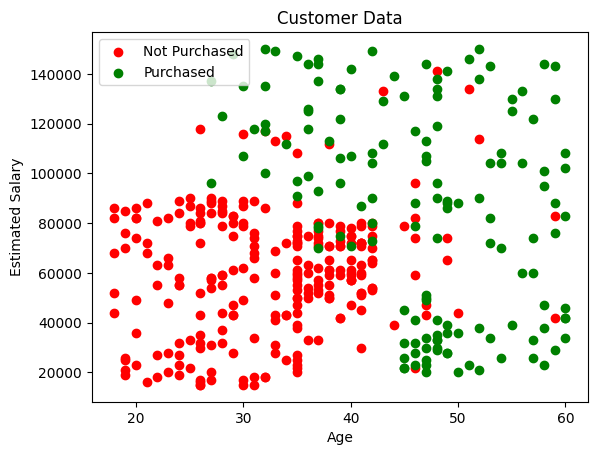

In [49]:
plt.scatter(X[y == 0, 0], X[y == 0, 1],
            c='red', label='Not Purchased')

plt.scatter(X[y == 1, 0], X[y == 1, 1],
            c='green', label='Purchased')

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Customer Data")
plt.legend()
plt.show()


### Red points represent customers who did not buy the car.Green points represent customers who bought the car. We can see some separation, so Logistic Regression is suitable

### Train-test split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=0.20, random_state=42)

# 80 % data is used for training, 20% for testing.

### feature scaling

In [30]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Feature scaling ensures that no feature dominates
# the model due to large values.

### Train logistic model

In [31]:
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

### Extract coefficient

In [ ]:
w1, w2 = model.coef_[0]
b = model.intercept_[0]

print("Coeff:", w1,w2)
print("Intercept:", b)

Coeff: 1.965097837355362 1.1350902087855854
Intercept: -0.9950491589967495


### Make Predictions

In [32]:
y_pred = model.predict(X_test)
print(y_pred)

# 0 -->  Customer will NOT buy
# 1 --> Customer WILL buy

[0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 0 1 0 1 0 0 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0
 0 0 1 1 0 0]


### Confusion matrix

In [51]:
confMatrix = confusion_matrix(y_test, y_pred)
print(confMatrix)

# 50 --> Correctly predicted YES purchase
# 19 --> Correctly predicted NO purchase
# 2 --> Predicted YES but actually NO
# 9 --> Predicted NO but actually YES

[[50  2]
 [ 9 19]]


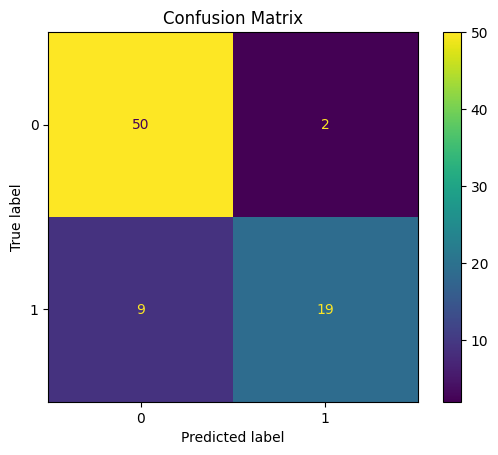

In [36]:
disp = ConfusionMatrixDisplay(confusion_matrix=confMatrix)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

### Accuracy of the model

In [39]:
# It represents the percentage of correctly predicted customers.

accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.8625


### Visualising decision boundary


Decision boundary is visualized on training data for understanding.
Test data is used only for evaluation

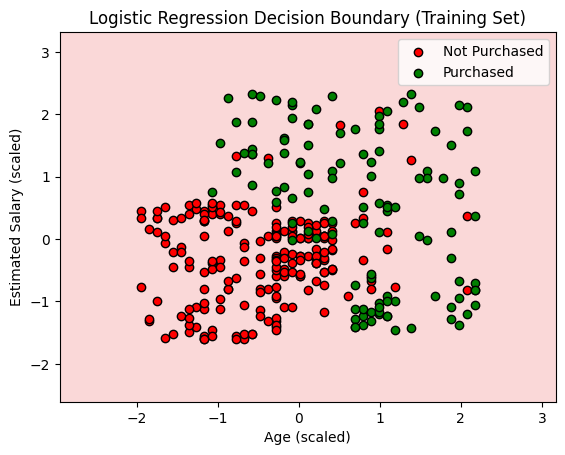

In [52]:

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.linspace(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 300),
    np.linspace(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 300)
)

probs = classifier.predict_proba(
    np.c_[X1.ravel(), X2.ravel()]
)[:, 1]
probs = probs.reshape(X1.shape)

plt.contourf(
    X1, X2,
    probs >= 0.5,
    alpha=0.3,
    cmap=ListedColormap(('lightcoral', 'lightgreen'))
)

plt.contour(
    X1, X2,
    probs,
    levels=[0.5],
    colors='black',
    linewidths=2
)

plt.scatter(
    X_set[y_set == 0, 0], X_set[y_set == 0, 1],
    c='red', label='Not Purchased', edgecolor='k'
)

plt.scatter(
    X_set[y_set == 1, 0], X_set[y_set == 1, 1],
    c='green', label='Purchased', edgecolor='k'
)

plt.title("Logistic Regression Decision Boundary (Training Set)")
plt.xlabel("Age (scaled)")
plt.ylabel("Estimated Salary (scaled)")
plt.legend()
plt.show()


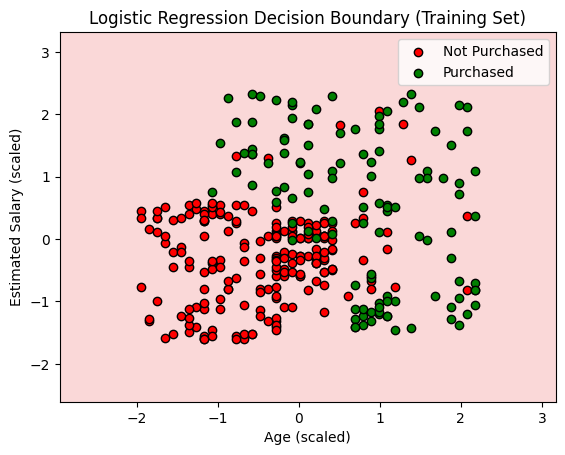

In [60]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_train, y_train

# Meshgrid
X1, X2 = np.meshgrid(
    np.linspace(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 300),
    np.linspace(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 300)
)


Z = classifier.predict(np.c_[X1.ravel(), X2.ravel()])
Z = Z.reshape(X1.shape)


plt.contourf(
    X1, X2, Z,
    alpha=0.3,
    cmap=ListedColormap(('lightcoral', 'lightgreen'))
)

probs = classifier.predict_proba(np.c_[X1.ravel(), X2.ravel()])[:, 1]
probs = probs.reshape(X1.shape)

plt.contour(
    X1, X2, probs,
    levels=[0.5],
    colors='black',
    linewidths=2
)


plt.scatter(
    X_set[y_set == 0, 0], X_set[y_set == 0, 1],
    c='red', label='Not Purchased', edgecolor='k'
)

plt.scatter(
    X_set[y_set == 1, 0], X_set[y_set == 1, 1],
    c='green', label='Purchased', edgecolor='k'
)

plt.title("Logistic Regression Decision Boundary (Training Set)")
plt.xlabel("Age (scaled)")
plt.ylabel("Estimated Salary (scaled)")
plt.legend()
plt.show()


In [62]:
probs = probs.reshape(X1.shape)
print(probs)

[[6.04201006e-06 6.06776858e-06 6.09363691e-06 ... 2.13749294e-05
  2.14660544e-05 2.15575678e-05]
 [6.04201432e-06 6.06777285e-06 6.09364119e-06 ... 2.13749444e-05
  2.14660695e-05 2.15575830e-05]
 [6.04201857e-06 6.06777712e-06 6.09364548e-06 ... 2.13749595e-05
  2.14660846e-05 2.15575981e-05]
 ...
 [6.04327292e-06 6.06903681e-06 6.09491055e-06 ... 2.13793970e-05
  2.14705410e-05 2.15620735e-05]
 [6.04327717e-06 6.06904109e-06 6.09491484e-06 ... 2.13794120e-05
  2.14705561e-05 2.15620887e-05]
 [6.04328142e-06 6.06904536e-06 6.09491913e-06 ... 2.13794270e-05
  2.14705712e-05 2.15621039e-05]]
